# High-dimensional Optimal Transport &mdash; ICNN-family + HyCNN estimators

This notebook is a fully self-contained companion to
[`Public/OT_maps.ipynb`](OT_maps.ipynb).  Where the 2D notebook trains a
**HyCNN** Brenier-potential pair on synthetic 2D distributions, this
notebook trains **four convex potential estimators side by side** on the
closed-form optimal-transport problem induced by the convex potential
$\psi$ in $\mathbb{R}^{50}$.

All four estimators are configured exactly as in the
`ot_superQuick_sweep.json` config used in the OT_SIMS reference sweeps.

## 0.1 The $\psi$ ground truth

$\psi$ is the strongly convex, anisotropic quadratic potential

$$
\psi(x) \;=\; \tfrac{1}{2} \sum_{i=1}^{d} s_i\, x_i^{2},
\qquad s_i \;=\; 1 + \tfrac{1}{2} \sin(i),
\qquad d = 50.
$$

By Brenier's theorem, the optimal-transport map from
$\mu = \mathcal{N}(0, I_d)$ to its pushforward $\nu = (\nabla \psi)_{\#}\mu$
is exactly $T^{\star}(x) = \nabla \psi(x) = (s_i x_i)_{i=1}^{d}$.
Recovering $T^{\star}$ amounts to learning the diagonal scaling
$s \in [0.5,\,1.5]^{d}$ from samples.

## 0.2 Estimators trained

Five runs spanning the four model classes of
`ot_superQuick_sweep.json`.  The first four are ICNN-family variants
(matching the legend of the published figures); the fifth is HyCNN.
Each run has its own $\tau$, so the labels match the *actual*
activation used at runtime.

| run | model class | width $\times$ depth | $\tau$ | activation | `lambda_cvx` | `enforce_inner_nonneg` |
| --- | --- | --- | --- | --- | --- | --- |
| ICNN (ReLU) | `ICNN` | $64 \times 4$ | 0 | $\mathrm{ReLU}(z)$ | 1.0 | `False` |
| ICNN (Leaky ReLU) | `ICNNLeaky` | $64 \times 4$ | 0 | $\max(z,\,0.2 z)$ | 1.0 | `False` |
| ICNN (ReLU, quad) | `ICNNQuad` | $64 \times 4$ | 0 | $\mathrm{ReLU}(z)$ on the augmented first layer | 1.0 | `False` |
| ICNN (Softplus, quad) | `ICNNQuad` | $64 \times 4$ | 1 | $\sigma_{1}(z) = \log(1 + e^{z})$ on the augmented first layer | 1.0 | `False` |
| HyCNN | `HyCNN` | $48 \times 4$ | 10 | $10 \log(e^{a/10} + e^{b/10})$ | 0.0 | `True` |

**`enforce_inner_nonneg` only governs the *inner* potential `g_net`.**
The *outer* potential `f_net` &mdash; whose gradient $\nabla f$ is our
transport-map estimator $\widehat T = \nabla f$ &mdash; is **always**
built convex by construction (softplus-reparameterised inner weights),
matching the reference workflow `_run_highdim_exact_map_workflow` in
`OT_resconet_sims/common/workflows.py`.

* `enforce_inner_nonneg=False` means `g_net`'s inner $V$-matrices are
  plain `nn.Linear` layers tagged with `weight.be_positive = True`; their
  non-negativity is then enforced *softly* by the convexity penalty
  $\lambda_{\mathrm{cvx}}\,\sum \|\mathrm{ReLU}(-W^{+})\|_{F}^{2}$
  applied during the inner update.
* `enforce_inner_nonneg=True` (HyCNN preset) routes `g_net`'s inner
  layers through `PositiveLinear` (softplus reparam), so they are
  non-negative *by construction* and the convexity penalty is redundant;
  in that regime `lambda_cvx` is set to 0.

## 0.3 Training settings

These hyperparameters are shared across the five runs; per-run
settings (architecture, $\tau$, `lambda_cvx`, `enforce_inner_nonneg`)
are listed in the table above.

| parameter | value |
| --- | --- |
| `iters` (outer) | 1000 |
| `inner_steps` | 5 |
| `batch_size` | 256 |
| `n_train` / `n_test` | 5000 / 1000 |
| `lr` | $10^{-2}$ |
| `lr_schedule` | cosine, `lr_final_ratio = 0.01` |
| `sample_seed` / `test_sample_seed` / `method_seed` | 5 / 15 / 10 |

## 0.4 Output

The final cell plots, for **a single training run per estimator**, the
held-out prediction MSE

$$
\mathrm{MSE}_T(f) \;=\; \mathbb{E}\bigl[\,\|\nabla f(X_{\mathrm{test}}) - T^{\star}(X_{\mathrm{test}})\|^{2}\bigr]
$$

as a function of the number of outer iterations on a $\log$-scale axis.


## 1 &middot; Imports and accelerator detection

The accelerator is picked automatically: CUDA &gt; MPS &gt; CPU.  All
training tensors are float32, which is the universal training dtype on
every backend.  CUDA-only TF32 flags are enabled when applicable.


In [1]:
from __future__ import annotations

import math
import random
import time
from dataclasses import dataclass
from typing import Sequence

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import ticker

plt.style.use('seaborn-v0_8-whitegrid')


def _resolve_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device('cuda')
    mps_backend = getattr(torch.backends, 'mps', None)
    if mps_backend is not None and mps_backend.is_available() and mps_backend.is_built():
        return torch.device('mps')
    return torch.device('cpu')


DEVICE = _resolve_device()
DTYPE = torch.float32
if DEVICE.type == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision('high')

print(f'device: {DEVICE}')
print(f'torch:  {torch.__version__}')
print(f'numpy:  {np.__version__}')


device: mps
torch:  2.9.1
numpy:  2.4.1


## 2 &middot; Convex potentials &mdash; `PositiveLinear`, `ICNN`, `ICNNLeaky`, `ICNNQuad`, `HyCNN`

All five layers share the structural rule that they are convex and
non-decreasing in the &ldquo;hidden&rdquo; activations of the previous
layer.  Concretely, a one-hidden-layer ICNN computes

$$
\psi_\theta(x) \;=\; W_{\mathrm{out}}^{+} \,\sigma\!\bigl(W_1^{+}\,\sigma(W_0 x + b_0) + W_1\,x + b_1\bigr) + W_{\mathrm{out}}\,x + b_{\mathrm{out}},
$$

where $W^{+}$ is non-negative (either by softplus reparameterisation, or
softly via a `lambda_cvx` penalty) and $\sigma$ is convex and
non-decreasing.

### `PositiveLinear`

Softplus-reparameterised non-negative `nn.Linear` with the
Hoedt-Klambauer ICNN init: $W^{+} = \mathrm{softplus}(W^{\mathrm{raw}})$
with $W^{\mathrm{raw}}$ drawn from a calibrated log-normal so first-layer
activations have unit second moment.

### `LinearQuadratic`

$x \mapsto W x + b + (V x)^{2}$ component-wise.  Convex in $x$ because
the squared terms compose a coordinate-wise non-negative square with an
affine inner.  Used as the first hidden layer of `ICNNQuad`.

### `ICNN`, `ICNNLeaky`, `ICNNQuad`

Standard Amos-style ICNN, Leaky-ReLU variant, and the quadratic
first-layer variant.  Each accepts an `enforce_nonneg` flag that toggles
between (a) softplus `PositiveLinear` $V$-matrices (`True`), and
(b) plain `nn.Linear` $V$-matrices tagged with `weight.be_positive = True`
for the soft-penalty regime (`False`).

**Activations are $\tau$-driven** (with one exception):

* `ICNN` and `ICNNQuad` use the $\tau$-parameterised softplus

  $$
  \sigma_\tau(z) \;=\; \tau \log\!\bigl(1 + e^{z / \tau}\bigr)
  \;\xrightarrow[\tau \to 0^{+}]{}\; \max(z, 0) \;=\; \mathrm{ReLU}(z),
  $$

  which is convex and non-decreasing for every $\tau > 0$ and reduces to
  ReLU at $\tau = 0$.  Implemented as `F.softplus(z, beta=1/tau)` for
  $\tau > 0$ and `F.relu(z)` for $\tau = 0$.
* `ICNNLeaky` always uses $z \mapsto \max(z,\, 0.2\,z)$ regardless of
  $\tau$.  $\tau$ is stored on the module for parity but not consumed.

### `HyCNN`

Two-branch partially input-convex network ported from
`Public/OT_maps.ipynb`.  At every layer two convex-preserving
pre-activations $a_1^{(\ell)}, a_2^{(\ell)}$ are combined via the
$\tau$-driven gate

$$
z^{(\ell)} \;=\;
\begin{cases}
\max\!\bigl(a_1^{(\ell)},\, a_2^{(\ell)}\bigr) & \text{if } \tau = 0, \\[2pt]
\tau \log\!\bigl(e^{a_1^{(\ell)}/\tau} + e^{a_2^{(\ell)}/\tau}\bigr) & \text{if } \tau > 0.
\end{cases}
$$

Both branches are convex and non-decreasing in their pre-activations.
Each run uses a fixed temperature `tau` (specified per-run in section 3).


In [2]:
def _hk_moments(fan_in: int) -> tuple[float, float, float]:
    """Hoedt-Klambauer ICNN moments."""
    if fan_in <= 0:
        raise ValueError('fan_in must be positive for ICNN initialization.')
    n = float(fan_in)
    denom = 6.0 * (math.pi - 1.0) + (n - 1.0) * (3.0 * math.sqrt(3.0) + 2.0 * math.pi - 6.0)
    mu = math.sqrt(6.0 * math.pi / (n * denom))
    sigma2 = 1.0 / n
    mu_b = -math.sqrt(3.0 * n / denom)
    return mu, sigma2, mu_b


def _lognormal_params_from_mean_var(mean: float, var: float) -> tuple[float, float]:
    if mean <= 0.0 or var < 0.0:
        raise ValueError('invalid lognormal moments')
    tau_lognorm = mean * mean + var
    return (math.log(mean * mean / math.sqrt(tau_lognorm)),
            math.log(tau_lognorm / (mean * mean)))


def _lecun_normal_(linear: nn.Linear) -> None:
    nn.init.normal_(linear.weight, 0.0, math.sqrt(1.0 / float(linear.in_features)))


def _quadratic_projection_std(fan_in: int) -> float:
    if fan_in <= 0:
        raise ValueError('fan_in must be positive for quadratic projection initialization.')
    return math.sqrt(1.0 / float(fan_in))


class PositiveLinear(nn.Module):
    """Positive linear layer with softplus reparameterisation and Hoedt-Klambauer init."""

    def __init__(self, in_features: int, out_features: int, bias: bool = False):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight_raw = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features)) if bias else None
        self.reset_parameters()

    def reset_parameters(self) -> None:
        with torch.no_grad():
            mu, sigma2, _ = _hk_moments(self.in_features)
            mu_ln, sigma2_ln = _lognormal_params_from_mean_var(mu, sigma2)
            pos = torch.exp(torch.randn_like(self.weight_raw) * math.sqrt(sigma2_ln) + mu_ln)
            pos = pos.clamp_min(torch.finfo(pos.dtype).tiny)
            # Invert softplus: W_raw = log(exp(W) - 1)
            self.weight_raw.copy_(torch.log(torch.expm1(pos)))
            if self.bias is not None:
                _, _, mu_b = _hk_moments(self.in_features)
                self.bias.fill_(mu_b)

    @property
    def weight(self) -> torch.Tensor:
        return F.softplus(self.weight_raw)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.linear(x, self.weight, self.bias)


class LinearQuadratic(nn.Module):
    """Affine map plus a learned per-output rank-1 quadratic term: W x + b + (V x)^2."""

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.quadratic_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.reset_quadratic_parameters()

    @property
    def bias(self):
        return self.linear.bias

    @torch.no_grad()
    def reset_quadratic_parameters(self, *, std: float | None = None) -> None:
        nn.init.normal_(
            self.quadratic_weight,
            0.0,
            _quadratic_projection_std(self.in_features) if std is None else float(std),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        quadratic_term = F.linear(x, self.quadratic_weight, None).pow(2)
        return self.linear(x) + quadratic_term


@torch.no_grad()
def _reset_icnn_quad_first_layer(layer: LinearQuadratic) -> None:
    _lecun_normal_(layer.linear)
    layer.reset_quadratic_parameters(std=_quadratic_projection_std(layer.in_features))
    _, _, mu_b0 = _hk_moments(layer.in_features)
    assert layer.bias is not None
    layer.bias.fill_(mu_b0)


def _make_icnn_inner_linear(in_features: int, out_features: int, *, enforce_nonneg: bool) -> nn.Module:
    """Build the inner V-matrix of an ICNN-family layer.

    * ``enforce_nonneg=True``  -> ``PositiveLinear`` (softplus, non-negative by construction).
    * ``enforce_nonneg=False`` -> plain ``nn.Linear`` whose weight is tagged
      ``be_positive=True``; the convexity penalty in the training loop
      then keeps it approximately non-negative.
    """
    if enforce_nonneg:
        return PositiveLinear(in_features, out_features, bias=False)
    layer = nn.Linear(in_features, out_features, bias=False)
    layer.weight.be_positive = True
    return layer


@torch.no_grad()
def _init_icnn_inner_linear(layer: nn.Module) -> None:
    if isinstance(layer, PositiveLinear):
        layer.reset_parameters()
        return
    mu, sigma2, _ = _hk_moments(layer.in_features)
    nn.init.normal_(layer.weight, mu, math.sqrt(sigma2))


class ICNN(nn.Module):
    """Amos-style Input-Convex Neural Network with a tau-parameterised activation.

    The activation is
      * ``F.relu(z)``                       when ``tau == 0``,
      * ``F.softplus(z, beta=1/tau)``       when ``tau > 0``,
    which is exactly  ``sigma_tau(z) = tau * log(1 + exp(z/tau))`` and
    converges to ``ReLU(z)`` as ``tau -> 0``.  Subclasses can override
    ``_activation`` (e.g. ``ICNNLeaky`` does so to use a fixed Leaky-ReLU).
    """

    def __init__(self, input_dim: int, hidden_dims: Sequence[int],
                 enforce_nonneg: bool = True, tau: float = 0.0):
        super().__init__()
        if len(hidden_dims) == 0:
            raise ValueError('ICNN needs hidden layers')
        if tau < 0.0:
            raise ValueError('tau must be non-negative.')
        self.input_dim = input_dim
        self.hidden_dims = tuple(int(h) for h in hidden_dims)
        self.enforce_nonneg = bool(enforce_nonneg)
        self.tau = float(tau)
        self.Wx0 = nn.Linear(input_dim, self.hidden_dims[0], bias=True)
        self.Wz_layers = nn.ModuleList()
        self.Wx_layers = nn.ModuleList()
        for in_dim, out_dim in zip(self.hidden_dims[:-1], self.hidden_dims[1:]):
            self.Wz_layers.append(_make_icnn_inner_linear(in_dim, out_dim, enforce_nonneg=self.enforce_nonneg))
            self.Wx_layers.append(nn.Linear(input_dim, out_dim, bias=True))
        self.Wz_out = _make_icnn_inner_linear(self.hidden_dims[-1], 1, enforce_nonneg=self.enforce_nonneg)
        self.Wx_out = nn.Linear(input_dim, 1, bias=True)
        self._reset_parameters()

    @torch.no_grad()
    def _reset_parameters(self) -> None:
        if isinstance(self.Wx0, LinearQuadratic):
            _reset_icnn_quad_first_layer(self.Wx0)
        else:
            _lecun_normal_(self.Wx0)
            _, _, mu_b0 = _hk_moments(self.Wx0.in_features)
            self.Wx0.bias.fill_(mu_b0)
        for wz, wx in zip(self.Wz_layers, self.Wx_layers):
            _init_icnn_inner_linear(wz)
            _lecun_normal_(wx)
            _, _, mu_b = _hk_moments(wz.in_features)
            wx.bias.fill_(mu_b)
        _init_icnn_inner_linear(self.Wz_out)
        _lecun_normal_(self.Wx_out)
        self.Wx_out.bias.zero_()

    def _activation(self, z: torch.Tensor) -> torch.Tensor:
        """tau-driven activation: ReLU when tau == 0, softplus_tau otherwise."""
        if self.tau <= 0.0:
            return F.relu(z)
        return F.softplus(z, beta=1.0 / self.tau)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self._activation(self.Wx0(x))
        for wz, wx in zip(self.Wz_layers, self.Wx_layers):
            z = self._activation(wz(z) + wx(x))
        return self.Wz_out(z) + self.Wx_out(x)


class ICNNLeaky(ICNN):
    """ICNN with a fixed Leaky-ReLU activation  z -> max(z, negative_slope * z).

    ``tau`` is accepted for API parity with the other ICNN classes but is
    NOT used by the activation -- the gate is always ``LeakyReLU(0.2)``.
    """

    def __init__(self, input_dim: int, hidden_dims: Sequence[int],
                 negative_slope: float = 0.2, enforce_nonneg: bool = True,
                 tau: float = 0.0):
        if negative_slope < 0.0:
            raise ValueError('negative_slope must be nonnegative.')
        self.negative_slope = float(negative_slope)
        super().__init__(input_dim=input_dim, hidden_dims=hidden_dims,
                         enforce_nonneg=enforce_nonneg, tau=tau)
        self._leaky = nn.LeakyReLU(negative_slope=self.negative_slope)

    def _activation(self, z: torch.Tensor) -> torch.Tensor:
        return self._leaky(z)


class ICNNQuad(ICNN):
    """ICNN whose first hidden layer is sigma_tau(W x + b + (V x)^2).

    Inherits the tau-driven activation (ReLU at tau=0, softplus_tau otherwise).
    """

    def __init__(self, input_dim: int, hidden_dims: Sequence[int],
                 enforce_nonneg: bool = True, tau: float = 0.0):
        super().__init__(input_dim=input_dim, hidden_dims=hidden_dims,
                         enforce_nonneg=enforce_nonneg, tau=tau)
        self.Wx0 = LinearQuadratic(input_dim, self.hidden_dims[0], bias=True)
        _reset_icnn_quad_first_layer(self.Wx0)


class HyCNN(nn.Module):
    """Hyper Input Convex Neural Network: two-branch log-sum-exp gates.

    Verbatim port of the ``HyCNN`` class in ``Public/OT_maps.ipynb``.  The
    inner V-matrices are always ``PositiveLinear`` (softplus, non-negative
    by construction), so no convexity penalty is needed and `lambda_cvx`
    is set to 0 in the public preset.
    """

    def __init__(self, input_dim: int, hidden_dims: Sequence[int],
                 activation: str = 'logsumexp', tau: float = 1.0):
        super().__init__()
        if len(hidden_dims) == 0:
            raise ValueError('HyCNN needs hidden layers')
        self.activation = activation.lower()
        if self.activation not in {'max', 'logsumexp', 'lse'}:
            raise ValueError("activation must be 'max' or 'logsumexp'")
        self.tau = float(tau)
        self.tail_tau = float(tau)
        self.input_dim = input_dim
        self.hidden_dims = tuple(int(h) for h in hidden_dims)
        self.num_gate_layers = len(self.hidden_dims)

        first = self.hidden_dims[0]
        self.W0_gates = nn.ModuleList([
            nn.Linear(input_dim, first),
            nn.Linear(input_dim, first),
        ])
        self.layers = nn.ModuleList()
        for in_dim, out_dim in zip(self.hidden_dims[:-1], self.hidden_dims[1:]):
            self.layers.append(nn.ModuleDict({
                'V_gates': nn.ModuleList([
                    PositiveLinear(in_dim, out_dim, bias=False),
                    PositiveLinear(in_dim, out_dim, bias=False),
                ]),
                'W_gates': nn.ModuleList([
                    nn.Linear(input_dim, out_dim),
                    nn.Linear(input_dim, out_dim),
                ]),
            }))
        self.V_out = PositiveLinear(self.hidden_dims[-1], 1, bias=False)
        self.W_out = nn.Linear(input_dim, 1)
        self._reset_parameters(input_dim)

    @torch.no_grad()
    def _reset_parameters(self, input_dim: int) -> None:
        w0_std = math.sqrt(1.0 / input_dim)
        for gate in self.W0_gates:
            nn.init.normal_(gate.weight, 0.0, w0_std)
            gate.bias.zero_()
        wl_std = math.sqrt(1.0 / (4.0 * input_dim))
        for layer in self.layers:
            out_dim = layer['W_gates'][0].out_features
            bias_val = -math.sqrt(out_dim / (2.0 * math.pi * out_dim + (2.0 * math.pi - 2.0)))
            for gate in layer['W_gates']:
                nn.init.normal_(gate.weight, 0.0, wl_std)
                gate.bias.fill_(bias_val)
            for v in layer['V_gates']:
                v.reset_parameters()
        self.V_out.reset_parameters()
        nn.init.normal_(self.W_out.weight, 0.0, wl_std)
        self.W_out.bias.fill_(-math.sqrt(1.0 / (2.0 * math.pi + 2.0 * math.pi - 2.0)))

    def _logsumexp(self, a: torch.Tensor, b: torch.Tensor, tau: float) -> torch.Tensor:
        if tau <= torch.finfo(a.dtype).eps:
            return torch.maximum(a, b)
        stacked = torch.stack((a, b), dim=0)
        return tau * torch.logsumexp(stacked / tau, dim=0)

    def _tau_for_layer(self, layer_idx: int) -> float:
        if layer_idx >= max(0, self.num_gate_layers - 2):
            return self.tail_tau
        return self.tau

    def _gate(self, a: torch.Tensor, b: torch.Tensor, layer_idx: int) -> torch.Tensor:
        if self.activation == 'max':
            return torch.maximum(a, b)
        return self._logsumexp(a, b, self._tau_for_layer(layer_idx))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self._gate(self.W0_gates[0](x), self.W0_gates[1](x), 0)
        for layer_idx, layer in enumerate(self.layers, start=1):
            a1 = layer['V_gates'][0](z) + layer['W_gates'][0](x)
            a2 = layer['V_gates'][1](z) + layer['W_gates'][1](x)
            z = self._gate(a1, a2, layer_idx)
        return self.V_out(z) + self.W_out(x)


def set_tau(module: nn.Module, tau: float) -> None:
    """Update ``tau`` on every HyCNN and ICNN-family submodule.

    For ``HyCNN``, ``tau`` drives the smooth-max gate (``max`` if
    ``tau == 0``, else ``logsumexp_tau``).  For ``ICNN`` and ``ICNNQuad``
    it drives the activation (``ReLU`` if ``tau == 0``, else
    ``softplus_tau``).  For ``ICNNLeaky`` ``tau`` is stored but not
    consumed -- the activation is always ``LeakyReLU(0.2)``.
    """
    for child in module.modules():
        if isinstance(child, HyCNN):
            child.tau = float(tau)
            child.tail_tau = float(tau)
        elif isinstance(child, ICNN):  # also covers ICNNLeaky and ICNNQuad
            child.tau = float(tau)


def build_potential(model_name: str, input_dim: int, hidden_dims: Sequence[int],
                    *, enforce_nonneg: bool = True, tau: float = 0.0) -> nn.Module:
    """Factory for the four convex potential families.

    ``model_name`` must be one of ``'icnn'``, ``'icnn_leaky'``,
    ``'icnn_quad'``, or ``'hycnn'``.  ``enforce_nonneg`` is forwarded to the
    ICNN family.  ``tau`` is forwarded to every family; see ``set_tau``
    for the per-family meaning.
    """
    name = model_name.lower()
    if name == 'icnn':
        return ICNN(input_dim=input_dim, hidden_dims=hidden_dims,
                    enforce_nonneg=enforce_nonneg, tau=float(tau))
    if name in {'icnn_leaky', 'icnn-leaky'}:
        return ICNNLeaky(input_dim=input_dim, hidden_dims=hidden_dims,
                         enforce_nonneg=enforce_nonneg, tau=float(tau))
    if name in {'icnn_quad', 'icnn-quad'}:
        return ICNNQuad(input_dim=input_dim, hidden_dims=hidden_dims,
                        enforce_nonneg=enforce_nonneg, tau=float(tau))
    if name == 'hycnn':
        return HyCNN(input_dim=input_dim, hidden_dims=hidden_dims,
                     activation='logsumexp', tau=float(tau))
    raise ValueError(
        "Unsupported model_name '" + str(model_name) + "'. "
        "Supported values: 'icnn', 'icnn_leaky', 'icnn_quad', 'hycnn'."
    )


def transport(net: nn.Module, x: torch.Tensor) -> torch.Tensor:
    """Brenier transport map T(x) = grad f(x)."""
    x_req = x.detach().clone().requires_grad_(True)
    y = net(x_req)
    grad = torch.autograd.grad(y.sum(), x_req, create_graph=False)[0]
    return grad.detach()


## 3 &middot; Configuration

`OTHighDimMapConfig` carries the per-run hyperparameters.  All four runs
share the training schedule (`_COMMON`, taken from
`ot_superQuick_sweep.json`).  The four `CONFIGS` entries differ only in
their architectural fields (`model`, `num_neuron`, `num_layers`,
`enforce_nonneg`) and `lambda_cvx`.


In [ ]:
@dataclass
class OTHighDimMapConfig:
    """Hyper-parameters for one high-dimensional OT-map run.

    ``enforce_inner_nonneg`` controls only the inner potential ``g_net``;
    the outer potential ``f_net`` is always built convex by construction.
    See ``train_semidual``.
    """
    run_name: str
    model: str
    num_neuron: int
    num_layers: int
    enforce_inner_nonneg: bool
    lambda_cvx: float
    input_dim: int
    n_train: int
    n_test: int
    iters: int
    inner_steps: int
    batch_size: int
    lr: float
    lr_schedule: str
    lr_final_ratio: float
    sample_seed: int
    test_sample_seed: int
    method_seed: int
    tau: float             # smoothing temperature; see set_tau for per-family meaning
    mse_every: int = 100    # cadence of held-out MSE evaluations
    log_every: int = 100   # cadence of training-progress prints


# Shared training settings, taken verbatim from ot_superQuick_sweep.json
# (tau is per-run; see CONFIGS below).
_COMMON = dict(
    input_dim=50,
    n_train=5000,
    n_test=1000,
    iters=1000,
    inner_steps=5,
    batch_size=256,
    lr=1e-2,
    lr_schedule='cosine',
    lr_final_ratio=0.01,
    sample_seed=5,
    test_sample_seed=15,
    method_seed=10,
    mse_every=10,
    log_every=100,
)

# Per-architecture settings, matching the depth-4 entries of
# ot_superQuick_sweep.json plus the public Cowork HyCNN preset:
#   * ICNN family: 64 x 4, enforce_inner_nonneg=False, lambda_cvx=1
#   * HyCNN      : 48 x 4, enforce_inner_nonneg=True,  lambda_cvx=0
# tau is per-run so the labels match the actual activation:
#   ICNN (ReLU) / ICNN (ReLU, quad)         -> tau=0   (real ReLU)
#   ICNN (Leaky ReLU)                       -> tau=0   (LeakyReLU(0.2), tau-independent)
#   ICNN (Softplus, quad) / HyCNN (...)     -> tau=10  (smoothed activation)
CONFIGS: list[OTHighDimMapConfig] = [
    OTHighDimMapConfig(run_name='ICNN (ReLU)',
                       model='icnn',       num_neuron=64, num_layers=4,
                       enforce_inner_nonneg=False,lambda_cvx=1.0,
                       tau=0.0,  **_COMMON),
    OTHighDimMapConfig(run_name='ICNN (Leaky ReLU)',
                       model='icnn_leaky', num_neuron=64, num_layers=4,
                       enforce_inner_nonneg=False,lambda_cvx=1.0,
                       tau=0.0,  **_COMMON),
    OTHighDimMapConfig(run_name='ICNN (ReLU, quad)',
                       model='icnn_quad',  num_neuron=64, num_layers=4,
                       enforce_inner_nonneg=False,lambda_cvx=1.0,
                       tau=0.0,  **_COMMON),
    OTHighDimMapConfig(run_name='ICNN (Softplus, quad)',
                       model='icnn_quad',  num_neuron=64, num_layers=4,
                       enforce_inner_nonneg=False,lambda_cvx=1.0,
                       tau=1.0, **_COMMON),
    OTHighDimMapConfig(run_name='HyCNN',
                       model='hycnn',      num_neuron=48, num_layers=4,
                       enforce_inner_nonneg=True, lambda_cvx=0.0,
                       tau=10.0, **_COMMON),
]

for cfg in CONFIGS:
    print(
        f"  {cfg.run_name:>43s}: {cfg.num_neuron}x{cfg.num_layers}, "
        f"enforce_inner_nonneg={str(cfg.enforce_inner_nonneg):>5s}, "
        f"lambda_cvx={cfg.lambda_cvx}, "
        f"tau={cfg.tau}"
    )


                                  ICNN (ReLU): 64x4, enforce_inner_nonneg=False, lambda_cvx=1.0, tau=0.0
                            ICNN (Leaky ReLU): 64x4, enforce_inner_nonneg=False, lambda_cvx=1.0, tau=0.0
                            ICNN (ReLU, quad): 64x4, enforce_inner_nonneg=False, lambda_cvx=1.0, tau=0.0
                        ICNN (Softplus, quad): 64x4, enforce_inner_nonneg=False, lambda_cvx=1.0, tau=1.0
                                        HyCNN: 48x4, enforce_inner_nonneg= True, lambda_cvx=0.0, tau=10.0


## 4 &middot; $\psi$ ground truth and the data pools

We sample two **independent** standard-normal pools of size `n_train`
(seeded by `sample_seed` and `sample_seed + 5000`), use the second pool
to build $Y^{(j)} = T^{\star}(X'^{(j)})$, and reserve a fresh paired
test set $(X_{\mathrm{test}}, Y_{\mathrm{test}} = T^{\star}(X_{\mathrm{test}}))$
(seeded by `test_sample_seed`) for evaluation.  The training pools are
therefore unpaired &mdash; this matches the genuine semi-dual setup
rather than a paired regression on $(X, T^{\star}(X))$.


In [4]:
def make_psi4_weights(d: int, *, device: torch.device, dtype: torch.dtype = DTYPE) -> torch.Tensor:
    coord_ids = torch.arange(1, d + 1, dtype=dtype, device=device)
    return 1.0 + 0.5 * torch.sin(coord_ids)


def psi4_potential(x: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    return 0.5 * torch.sum(x.pow(2) * weights.unsqueeze(0), dim=1, keepdim=True)


def psi4_transport(x: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    return x * weights.unsqueeze(0)


def sample_psi4_pools(
    *, n_train: int, n_test: int, input_dim: int,
    sample_seed: int, test_sample_seed: int,
    device: torch.device, dtype: torch.dtype = DTYPE,
):
    """Independent source/target pools and a paired test set for psi."""
    weights = make_psi4_weights(input_dim, device=device, dtype=dtype)

    g_src = torch.Generator(device='cpu').manual_seed(int(sample_seed))
    g_tgt = torch.Generator(device='cpu').manual_seed(int(sample_seed) + 5000)
    g_te  = torch.Generator(device='cpu').manual_seed(int(test_sample_seed))

    x_pool = torch.randn(n_train, input_dim, generator=g_src, dtype=dtype).to(device)
    x_for_target = torch.randn(n_train, input_dim, generator=g_tgt, dtype=dtype).to(device)
    y_pool = psi4_transport(x_for_target, weights)

    x_test = torch.randn(n_test, input_dim, generator=g_te, dtype=dtype).to(device)
    y_test = psi4_transport(x_test, weights)
    return x_pool, y_pool, x_test, y_test, weights


DATA_CFG = CONFIGS[0]
X_POOL, Y_POOL, X_TEST, Y_TEST, PSI4_WEIGHTS = sample_psi4_pools(
    n_train=DATA_CFG.n_train,
    n_test=DATA_CFG.n_test,
    input_dim=DATA_CFG.input_dim,
    sample_seed=DATA_CFG.sample_seed,
    test_sample_seed=DATA_CFG.test_sample_seed,
    device=DEVICE,
)
print(
    f'psi_4 per-coordinate scaling: '
    f'min={float(PSI4_WEIGHTS.min()):.4f}, max={float(PSI4_WEIGHTS.max()):.4f}'
)
print(
    f'shapes: x_pool={tuple(X_POOL.shape)}, y_pool={tuple(Y_POOL.shape)}, '
    f'x_test={tuple(X_TEST.shape)}, y_test={tuple(Y_TEST.shape)}'
)


psi_4 per-coordinate scaling: min=0.5000, max=1.5000
shapes: x_pool=(5000, 50), y_pool=(5000, 50), x_test=(1000, 50), y_test=(1000, 50)


## 5 &middot; Cosine LR schedule and the semi-dual maximin training loop

### Cosine learning-rate schedule

$$
\mathrm{lr}(t) \;=\; \mathrm{lr}_{0}\,\Bigl(\,r + \tfrac{1-r}{2}\bigl(1 + \cos(\pi\, t/(T-1))\bigr)\,\Bigr),
\qquad t = 0, 1, \ldots, T-1,
$$

decaying from $\mathrm{lr}_0$ to $r\cdot\mathrm{lr}_0$.  Same
implementation as `Public/OT_maps.ipynb`.

### Convexity penalty

When the inner $V$-matrices are unconstrained (`enforce_nonneg=False`),
their non-negativity is enforced *softly* by the convexity penalty

$$
\Omega(g) \;=\; \sum_{W^{+}\,\text{positive}} \|\mathrm{ReLU}(-W^{+})\|_{F}^{2},
$$

applied with weight `lambda_cvx`.  The sum runs over every parameter that
carries the `be_positive=True` tag &mdash; for the ICNN family this is
the inner $V$-matrices.  HyCNN's $V$-matrices are softplus-reparameterised
and therefore non-negative by construction, so its `lambda_cvx` is 0.

### Semi-dual maximin loop

For each outer iteration $t = 0, \ldots, T - 1$:

1. update the LR via the cosine schedule above;
2. perform `inner_steps` Adam updates on the inner potential $g$
   minimising  $\mathcal{L}_{\mathrm{inner}}(g) = \mathbb{E}_\nu\bigl[f(\nabla g(Y)) - \langle Y, \nabla g(Y)\rangle\bigr] + \lambda_{\mathrm{cvx}}\,\Omega(g)$;
3. perform one Adam update on the outer potential $f$ minimising
   $\mathcal{L}_{\mathrm{outer}}(f) = \mathbb{E}_\mu[f(X)] - \mathbb{E}_\nu[f(\nabla g(Y))]$;
4. every `mse_every` outer iterations evaluate the held-out
   $\mathrm{MSE}_T = \mathbb{E}\bigl[\,\|\nabla f(X_{\mathrm{test}}) - T^{\star}(X_{\mathrm{test}})\|^{2}\bigr]$
   and append it to `mse_history`.

Both nets are differentiated to second order: we backprop *through*
$\nabla g(Y)$ when training $g$, and again when training $f$.


In [5]:
def scheduled_learning_rate(initial_lr: float, iteration: int, total_iters: int,
                            schedule: str, final_ratio: float) -> float:
    """Cosine LR schedule.

    Returns ``initial_lr * (final_ratio + 0.5*(1 - final_ratio)*(1 + cos(pi*t/(T-1))))``
    so the LR decays from ``initial_lr`` down to ``initial_lr * final_ratio``.
    """
    schedule_name = schedule.lower()
    if schedule_name == 'none' or total_iters <= 1:
        return float(initial_lr)
    if schedule_name != 'cosine':
        raise ValueError(f'Unsupported lr_schedule {schedule!r}.')
    if not 0.0 < final_ratio <= 1.0:
        raise ValueError('lr_final_ratio must lie in (0, 1].')
    progress = iteration / float(total_iters - 1)
    return float(
        initial_lr * (final_ratio + 0.5 * (1.0 - final_ratio) * (1.0 + math.cos(math.pi * progress)))
    )


def evaluate_transport_mse(f_net: nn.Module, x_test: torch.Tensor, y_test: torch.Tensor) -> float:
    mapped = transport(f_net, x_test)
    diff = (mapped - y_test).reshape(mapped.shape[0], -1)
    return float(torch.mean(torch.sum(diff.pow(2), dim=1)).detach().cpu())


def _resample_tensor_rows(pool: torch.Tensor, batch_size: int) -> torch.Tensor:
    """Sample `batch_size` rows from `pool` with replacement, on `pool.device`."""
    indices = torch.randint(pool.shape[0], (batch_size,), device=pool.device)
    return pool.index_select(0, indices)


def _seed_method(seed: int) -> None:
    """Seed Python ``random``, NumPy and PyTorch (CPU + CUDA + MPS)."""
    seed = int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # `torch.manual_seed` already seeds the MPS RNG when available.


def _convexity_penalty(net: nn.Module) -> torch.Tensor:
    """Sum of ReLU(-W)^2 over every parameter tagged ``be_positive=True``.

    Returns a zero-dim tensor on the network's device.
    """
    device = next(net.parameters()).device
    penalty = torch.zeros((), device=device)
    for param in net.parameters():
        if getattr(param, 'be_positive', False):
            penalty = penalty + torch.relu(-param).pow(2).sum()
    return penalty


@dataclass
class OTRunResult:
    """Container for the artefacts of a single training run."""
    config: OTHighDimMapConfig
    f_net: nn.Module
    g_net: nn.Module
    loss_history: list
    mse_history: list
    final_test_mse: float
    elapsed_seconds: float = 0.0


def train_semidual(
    config: OTHighDimMapConfig,
    *,
    x_pool: torch.Tensor,
    y_pool: torch.Tensor,
    x_test: torch.Tensor,
    y_test: torch.Tensor,
) -> OTRunResult:
    """Train one estimator on the supplied pools and return the result.

    Mirrors the optimisation step of ``run_ot_2d`` from
    ``Public/OT_maps.ipynb``: ``inner_steps`` Adam updates on $g$ followed
    by one Adam update on $f$, both with $\beta = (0.5, 0.9)$ and the
    cosine LR schedule.  When ``config.lambda_cvx > 0`` the inner update
    additionally penalises ``ReLU(-W^+)^2`` for every ``be_positive=True``
    parameter of ``g_net``.
    """
    _seed_method(config.method_seed)
    hidden_dims = [config.num_neuron] * config.num_layers
    # The OUTER potential f_net is ALWAYS built convex by construction
    # (softplus reparameterised inner V-matrices), since grad f(x) is
    # the transport-map estimator and must come from a convex potential.
    # Only the INNER potential g_net follows config.enforce_inner_nonneg;
    # when False, its V-matrices are unconstrained and the convexity
    # penalty (config.lambda_cvx) keeps them approximately non-negative.
    # This matches _run_highdim_exact_map_workflow exactly.
    f_net = build_potential(
        config.model, input_dim=config.input_dim, hidden_dims=hidden_dims,
        enforce_nonneg=True, tau=config.tau,
    ).to(DEVICE)
    g_net = build_potential(
        config.model, input_dim=config.input_dim, hidden_dims=hidden_dims,
        enforce_nonneg=config.enforce_inner_nonneg, tau=config.tau,
    ).to(DEVICE)
    f_opt = torch.optim.Adam(f_net.parameters(), lr=config.lr, betas=(0.5, 0.9))
    g_opt = torch.optim.Adam(g_net.parameters(), lr=config.lr, betas=(0.5, 0.9))

    x_pool = x_pool.to(DEVICE); y_pool = y_pool.to(DEVICE)
    x_test = x_test.to(DEVICE); y_test = y_test.to(DEVICE)

    print(
        f'  iters={config.iters}, batch={config.batch_size}, '
        f'inner_steps={config.inner_steps}, lr={config.lr}, '
        f'model={config.model} ({config.num_neuron}x{config.num_layers}), '
        f'enforce_inner_nonneg={config.enforce_inner_nonneg}, '
        f'lambda_cvx={config.lambda_cvx}, device={DEVICE}'
    )

    loss_history: list[dict] = []
    mse_history: list[dict] = []
    initial_mse = evaluate_transport_mse(f_net, x_test, y_test)
    mse_history.append({'iter': 0, 'mse': float(initial_mse)})

    last_inner_potential = float('nan')
    last_inner_objective = float('nan')
    last_inner_cvx_penalty = 0.0
    start_time = time.perf_counter()
    for it in range(config.iters):
        current_lr = scheduled_learning_rate(
            initial_lr=config.lr, iteration=it, total_iters=config.iters,
            schedule=config.lr_schedule, final_ratio=config.lr_final_ratio,
        )
        for opt in (f_opt, g_opt):
            for pg in opt.param_groups:
                pg['lr'] = current_lr

        # Inner steps: maximise over varphi  (equivalently, minimise its negative).
        for _ in range(config.inner_steps):
            y = _resample_tensor_rows(y_pool, config.batch_size)
            y.requires_grad_(True)
            grad_gy = torch.autograd.grad(g_net(y).sum(), y, create_graph=True)[0]
            inner_potential_loss = (f_net(grad_gy) - (y * grad_gy).sum(dim=1, keepdim=True)).mean()
            if config.lambda_cvx > 0:
                inner_cvx_penalty = _convexity_penalty(g_net)
                g_objective = inner_potential_loss + config.lambda_cvx * inner_cvx_penalty
                last_inner_cvx_penalty = float(inner_cvx_penalty.detach())
            else:
                g_objective = inner_potential_loss
                last_inner_cvx_penalty = 0.0
            g_opt.zero_grad(set_to_none=True)
            g_objective.backward()
            g_opt.step()
            last_inner_potential = float(inner_potential_loss.detach())
            last_inner_objective = float(g_objective.detach())

        # Outer step: minimise over psi.
        x = _resample_tensor_rows(x_pool, config.batch_size)
        y = _resample_tensor_rows(y_pool, config.batch_size)
        y.requires_grad_(True)
        grad_gy = torch.autograd.grad(g_net(y).sum(), y, create_graph=True)[0]
        outer_potential_loss = (f_net(x) - f_net(grad_gy)).mean()
        f_opt.zero_grad(set_to_none=True)
        outer_potential_loss.backward()
        f_opt.step()
        current_outer = float(outer_potential_loss.detach())

        loss_history.append(dict(
            iter=it + 1,
            outer_potential_loss=current_outer,
            inner_potential_loss=last_inner_potential,
            inner_objective=last_inner_objective,
            inner_cvx_penalty=last_inner_cvx_penalty,
            tau=float(config.tau),
            lr=current_lr,
        ))

        do_eval = ((it + 1) % config.mse_every == 0) or ((it + 1) == config.iters)
        if do_eval:
            mse_value = evaluate_transport_mse(f_net, x_test, y_test)
            mse_history.append({'iter': it + 1, 'mse': float(mse_value)})
            if config.log_every > 0 and ((it + 1) % config.log_every == 0 or (it + 1) == config.iters):
                print(
                    f'    [{config.run_name:>43s}] outer_iter={it+1:5d}/{config.iters}  '
                    f'outer_loss={current_outer:+.4f}  '
                    f'inner_loss={last_inner_potential:+.4f}  '
                    f'lr={current_lr:.2e}  test_MSE={mse_value:.6f}'
                )

    elapsed = time.perf_counter() - start_time
    final_test_mse = mse_history[-1]['mse']
    print(f'  final_test_mse={final_test_mse:.6f}   (elapsed {elapsed:.1f} s on {DEVICE})')

    return OTRunResult(
        config=config, f_net=f_net, g_net=g_net,
        loss_history=loss_history, mse_history=mse_history,
        final_test_mse=final_test_mse, elapsed_seconds=elapsed,
    )


## 6 &middot; Train all five estimators on $\psi_4$

All five runs &mdash; `ICNN (ReLU)`, `ICNN (Leaky ReLU)`,
`ICNN (ReLU, quad)`, `ICNN (Softplus, quad)`, and
`HyCNN` &mdash; are trained from a
freshly seeded initialisation with the per-run settings from `CONFIGS`
and the shared training schedule from `_COMMON`.


In [6]:
results: list[OTRunResult] = []
for cfg in CONFIGS:
    print(f"\n=== {cfg.run_name} ===")
    results.append(
        train_semidual(cfg, x_pool=X_POOL, y_pool=Y_POOL, x_test=X_TEST, y_test=Y_TEST)
    )

print('\nFinal test MSE by estimator:')
for result in results:
    print(f"  {result.config.run_name:>43s}:  {result.final_test_mse:.6f}")



=== ICNN (ReLU) ===
  iters=1000, batch=256, inner_steps=5, lr=0.01, model=icnn (64x4), enforce_inner_nonneg=False, lambda_cvx=1.0, device=mps
    [                                ICNN (ReLU)] outer_iter=  100/1000  outer_loss=-5475.7402  inner_loss=+587.9340  lr=9.76e-03  test_MSE=275.463654
    [                                ICNN (ReLU)] outer_iter=  200/1000  outer_loss=-223.8624  inner_loss=-8.5117  lr=9.06e-03  test_MSE=249.291382
    [                                ICNN (ReLU)] outer_iter=  300/1000  outer_loss=-27.4009  inner_loss=-39.6172  lr=7.97e-03  test_MSE=161.432587
    [                                ICNN (ReLU)] outer_iter=  400/1000  outer_loss=-0.7581  inner_loss=-36.6012  lr=6.59e-03  test_MSE=17.479586
    [                                ICNN (ReLU)] outer_iter=  500/1000  outer_loss=-0.9327  inner_loss=-36.7442  lr=5.06e-03  test_MSE=12.994499
    [                                ICNN (ReLU)] outer_iter=  600/1000  outer_loss=-0.4223  inner_loss=-34.8417  lr=

## 7 &middot; Prediction MSE vs. number of outer iterations

Single-run prediction MSE

$$
\mathrm{MSE}_T(f) \;=\; \mathbb{E}\bigl[\,\|\nabla f(X_{\mathrm{test}}) - T^{\star}(X_{\mathrm{test}})\|^{2}\bigr]
$$

is plotted against the outer iteration count on a log-scale axis, in
the same family-coloured style as the published figures.


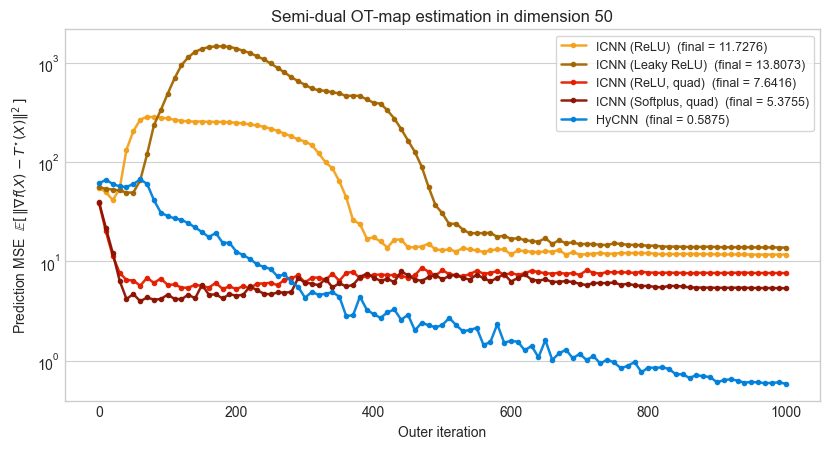

In [7]:
# Run -> colour mapping aligned with the published figure palette:
#   ICNN (ReLU)            : light orange
#   ICNN (Leaky ReLU)      : dark brown
#   ICNN (ReLU, quad)      : orange-red
#   ICNN (Softplus, quad)  : dark red
#   HyCNN (...)            : blue
RUN_COLORS = {
    'ICNN (ReLU)':                              '#f3a11c',
    'ICNN (Leaky ReLU)':                        '#a46500',
    'ICNN (ReLU, quad)':                        '#e31e00',
    'ICNN (Softplus, quad)':                    '#8b1301',
    'HyCNN': '#0080db',
}

MAJOR_Y_GRID_COLOR = '#c7c7c7'
MAJOR_Y_GRID_ALPHA = 0.85
MAJOR_Y_GRID_LINEWIDTH = 0.8

fig, ax = plt.subplots(1, 1, figsize=(8.4, 4.6))
for result in results:
    history = result.mse_history
    iters = [entry['iter'] for entry in history]
    mses  = [entry['mse']  for entry in history]
    label = f"{result.config.run_name}  (final = {mses[-1]:.4f})"
    ax.plot(
        iters, mses,
        color=RUN_COLORS[result.config.run_name],
        linewidth=1.8, alpha=0.95,
        marker='o', markersize=3.0,
        label=label,
    )

ax.set_xlabel('Outer iteration')
ax.set_ylabel(r'Prediction MSE  $\mathbb{E}[\,\|\nabla f(X) - T^{\star}(X)\|^{2}\,]$')
ax.set_title(
    r'Semi-dual OT-map estimation in dimension 50'
)
ax.set_yscale('log')
ax.set_axisbelow(True)
ax.xaxis.grid(False, which='both')
ax.yaxis.grid(True, which='major', color=MAJOR_Y_GRID_COLOR,
              alpha=MAJOR_Y_GRID_ALPHA, linewidth=MAJOR_Y_GRID_LINEWIDTH)
ax.yaxis.grid(False, which='minor')
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.tick_params(axis='y', which='minor', labelleft=False)
ax.legend(loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()
